/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(



SPLIT CUSTOMERS: TRAIN vs SIMULATION: TRAINING SIZE 0.75
Split: 17933 train, 5955 sim customers
Non-converted customers: 3999
✅ Loaded standardized price file
Shape: (1745, 17)
Columns: ['id_devis_type', 'num_devis_type', 'description_devis_type', 'nom_devis_type', 'dth_creation_devis_type', 'id_produit', 'nom_produit', 'cd_produit', 'famille_article_produit', 'famille_produit', 'famille_equipement_produit', 'marque_produit', 'modele_produit', 'type_equipement_produit', 'min_pv', 'max_pv', 'moy_pv']

✅ Loaded customer quotes
Shape: (5432, 48)
Unique customers: 3999
ACTUAL MARKET PRICES FROM CUSTOMER DATA

Actual prices by product family and brand:
      famille_equipement_produit      marque_produit  quote_count  avg_price  min_price  max_price  std_price
                Appareil hybride            ATLANTIC           44   14196.17    4013.67   19357.03    2266.85
                Appareil hybride              DAIKIN            1   12127.69   12127.69   12127.69        NaN
             

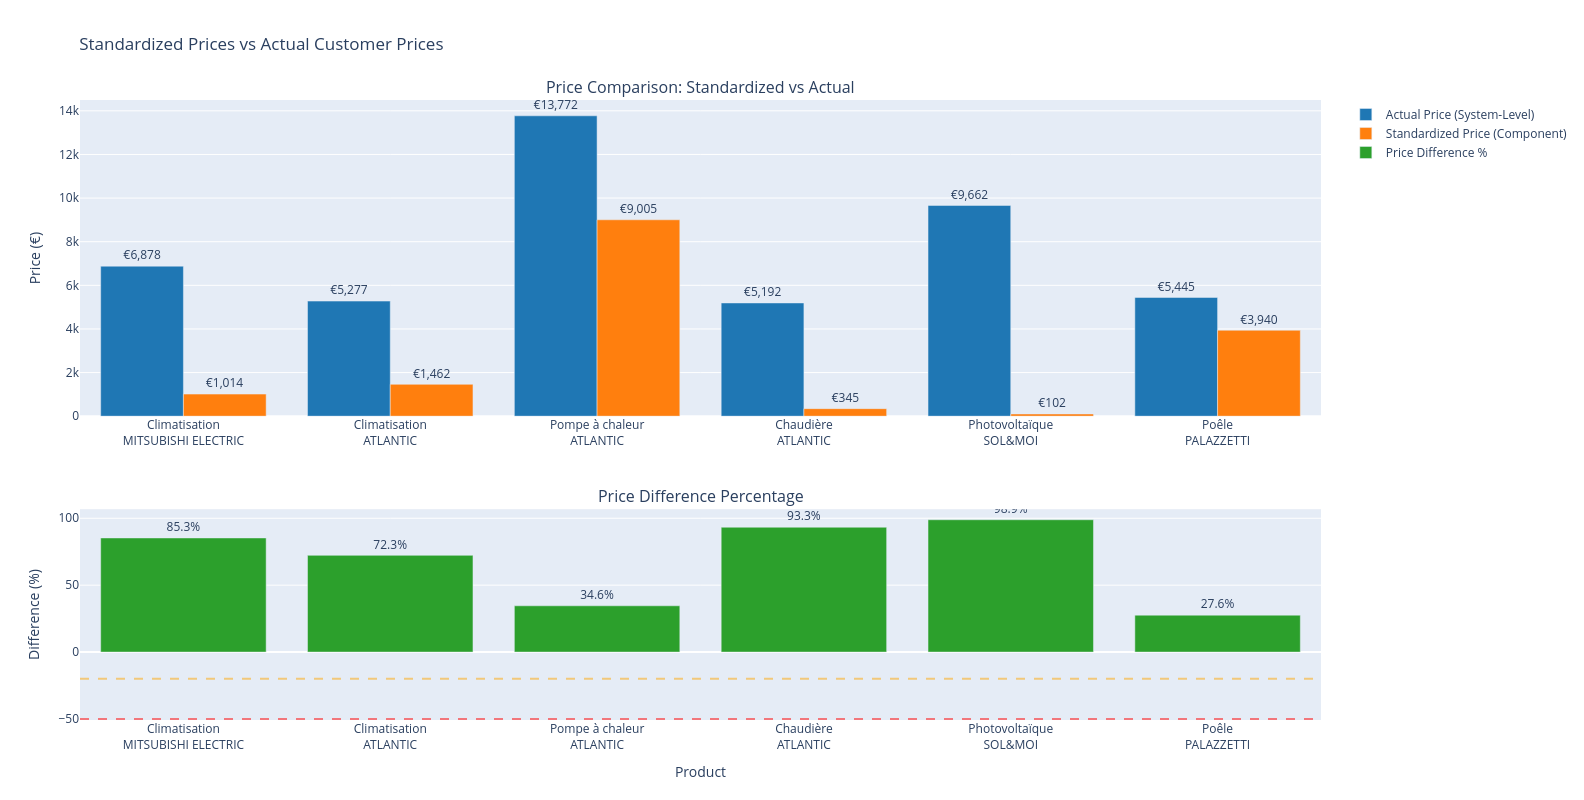

DETAILED ANALYSIS BY PRODUCT FAMILY

📊 Climatisation

  Brand: MITSUBISHI ELECTRIC
    • Actual price (system-level): €6,878.28
    • Standardized price (component): €1,013.67
    • Difference: €5,864.61 (85.3% lower)
    ✅ INTERPRETATION: Comparable pricing

  Brand: ATLANTIC
    • Actual price (system-level): €5,277.21
    • Standardized price (component): €1,461.75
    • Difference: €3,815.46 (72.3% lower)
    ✅ INTERPRETATION: Comparable pricing

📊 Pompe à chaleur

  Brand: ATLANTIC
    • Actual price (system-level): €13,771.73
    • Standardized price (component): €9,004.71
    • Difference: €4,767.02 (34.6% lower)
    ✅ INTERPRETATION: Comparable pricing

📊 Chaudière

  Brand: ATLANTIC
    • Actual price (system-level): €5,192.25
    • Standardized price (component): €345.36
    • Difference: €4,846.89 (93.3% lower)
    ✅ INTERPRETATION: Comparable pricing

📊 Photovoltaïque

  Brand: SOL&MOI
    • Actual price (system-level): €9,662.15
    • Standardized price (component): €102.2

In [1]:


# %%
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import pandas as pd
import pickle
import time

from ml_simulation.dataset_split import customer_split
from ml_simulation.util import HiddenPrints
from ml_features.features import create_features
from ml_training.train_lgb import train_lgb
from ml_simulation.segment import get_nonconverted_customers

from ml_simulation__standard_pricing.sample import sample_standardized_customers
from ml_simulation__standard_pricing.shift import simulate_standardized_pricing_conversion_shift
    
import warnings
warnings.filterwarnings('ignore')

df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

split_result = customer_split(df_quotes, train_size=0.75)
df_train = split_result['train']
df_sim = get_nonconverted_customers(split_result['simulation'])

# Load standardized price file
price_file = pd.read_csv('data/Liste_des_devis_type.csv', sep=';', encoding='latin-1')

# Clean price columns
for col in ['min_pv', 'max_pv', 'moy_pv']:
    price_file[col] = price_file[col].astype(str).str.replace(',', '.').astype(float)

print("✅ Loaded standardized price file")
print(f"Shape: {price_file.shape}")
print(f"Columns: {price_file.columns.tolist()}")

# Load customer quotes (assuming df_sim is already loaded)
print(f"\n✅ Loaded customer quotes")
print(f"Shape: {df_sim.shape}")
print(f"Unique customers: {df_sim['numero_compte'].nunique()}")

# %% [markdown]
# ## 2. Calculate Actual Market Prices from Customer Data

# %%
print("=" * 80)
print("ACTUAL MARKET PRICES FROM CUSTOMER DATA")
print("=" * 80)

# Calculate average prices by product family and brand
actual_prices = df_sim.groupby(['famille_equipement_produit', 'marque_produit']).agg({
    'mt_apres_remise_ht_devis': ['count', 'mean', 'min', 'max', 'std']
}).round(2)

actual_prices.columns = ['quote_count', 'avg_price', 'min_price', 'max_price', 'std_price']
actual_prices = actual_prices.reset_index()

print("\nActual prices by product family and brand:")
print(actual_prices.to_string(index=False))

# %% [markdown]
# ## 3. Extract Standardized Prices

# %%
print("=" * 80)
print("STANDARDIZED PRICES FROM PRICE FILE")
print("=" * 80)

# Extract key products
standardized_prices = price_file[
    price_file['famille_equipement_produit'].isin([
        'Climatisation', 'Pompe à chaleur', 'Chaudière', 
        'Photovoltaïque', 'Poêle'
    ])
].copy()

standardized_summary = standardized_prices.groupby(['famille_equipement_produit', 'marque_produit', 'type_equipement_produit']).agg({
    'min_pv': 'first',
    'max_pv': 'first',
    'moy_pv': 'first',
    'id_produit': 'count'
}).rename(columns={'id_produit': 'product_count'})

print("\nStandardized prices by product family and brand:")
print(standardized_summary.to_string())

# %% [markdown]
# ## 4. Create Comparison Table

# %%
print("=" * 80)
print("PRICE COMPARISON: STANDARDIZED VS ACTUAL")
print("=" * 80)

comparison_data = []

# Map of product families and brands to compare
comparison_map = [
    ('Climatisation', 'MITSUBISHI ELECTRIC'),
    ('Climatisation', 'ATLANTIC'),
    ('Pompe à chaleur', 'ATLANTIC'),
    ('Chaudière', 'ATLANTIC'),
    ('Photovoltaïque', 'SOL&MOI'),
    ('Poêle', 'PALAZZETTI')
]

for family, brand in comparison_map:
    # Get standardized price
    std_row = standardized_prices[
        (standardized_prices['famille_equipement_produit'] == family) &
        (standardized_prices['marque_produit'] == brand)
    ]
    
    if len(std_row) > 0:
        std_price = std_row['moy_pv'].iloc[0]
        std_min = std_row['min_pv'].iloc[0]
        std_max = std_row['max_pv'].iloc[0]
    else:
        std_price = std_min = std_max = np.nan
    
    # Get actual price
    actual_row = actual_prices[
        (actual_prices['famille_equipement_produit'] == family) &
        (actual_prices['marque_produit'] == brand)
    ]
    
    if len(actual_row) > 0:
        actual_price = actual_row['avg_price'].iloc[0]
        actual_count = actual_row['quote_count'].iloc[0]
    else:
        actual_price = np.nan
        actual_count = 0
    
    if not np.isnan(std_price) and not np.isnan(actual_price):
        difference = actual_price - std_price
        pct_diff = (difference / actual_price) * 100
        
        comparison_data.append({
            'Product Family': family,
            'Brand': brand,
            'Standardized Price (€)': f"{std_price:,.2f}",
            'Actual Price (€)': f"{actual_price:,.2f}",
            'Difference (€)': f"{difference:+,.2f}",
            'Difference (%)': f"{pct_diff:+.1f}%",
            'Quote Count': actual_count,
            'Interpretation': 'Component vs System' if pct_diff > 80 else 'Possible Component' if pct_diff > 20 else 'Similar'
        })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# %% [markdown]
# ## 5. Visualize the Discrepancy

# %%
# Create visualization
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Price Comparison: Standardized vs Actual', 'Price Difference Percentage'),
    vertical_spacing=0.15,
    row_heights=[0.6, 0.4]
)

# Bar chart for prices
products = [f"{row['Product Family']}<br>{row['Brand']}" for _, row in comparison_df.iterrows()]
actual_prices_vals = [float(row['Actual Price (€)'].replace(',', '')) for _, row in comparison_df.iterrows()]
std_prices_vals = [float(row['Standardized Price (€)'].replace(',', '')) for _, row in comparison_df.iterrows()]

fig.add_trace(
    go.Bar(name='Actual Price (System-Level)', x=products, y=actual_prices_vals, 
           marker_color='#1f77b4', text=[f"€{x:,.0f}" for x in actual_prices_vals], textposition='outside'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(name='Standardized Price (Component)', x=products, y=std_prices_vals,
           marker_color='#ff7f0e', text=[f"€{x:,.0f}" for x in std_prices_vals], textposition='outside'),
    row=1, col=1
)

# Percentage difference
pct_diffs = [float(row['Difference (%)'].replace('%', '').replace('+', '')) for _, row in comparison_df.iterrows()]

fig.add_trace(
    go.Bar(name='Price Difference %', x=products, y=pct_diffs,
           marker_color=['#d62728' if x < -50 else '#2ca02c' for x in pct_diffs],
           text=[f"{x:.1f}%" for x in pct_diffs], textposition='outside'),
    row=2, col=1
)

fig.add_hline(y=-50, line_dash="dash", line_color="red", opacity=0.5, row=2, col=1)
fig.add_hline(y=-20, line_dash="dash", line_color="orange", opacity=0.5, row=2, col=1)

fig.update_layout(
    title="Standardized Prices vs Actual Customer Prices",
    height=800,
    showlegend=True,
    barmode='group'
)

fig.update_xaxes(title_text="Product", row=2, col=1)
fig.update_yaxes(title_text="Price (€)", row=1, col=1)
fig.update_yaxes(title_text="Difference (%)", row=2, col=1, tickformat=".0f")

fig.show()

# %% [markdown]
# ## 6. Analysis by Product Family

# %%
print("=" * 80)
print("DETAILED ANALYSIS BY PRODUCT FAMILY")
print("=" * 80)

for family in comparison_df['Product Family'].unique():
    family_data = comparison_df[comparison_df['Product Family'] == family]
    
    print(f"\n{'='*60}")
    print(f"📊 {family}")
    print('='*60)
    
    for _, row in family_data.iterrows():
        actual = float(row['Actual Price (€)'].replace(',', ''))
        std = float(row['Standardized Price (€)'].replace(',', ''))
        pct = float(row['Difference (%)'].replace('%', '').replace('+', ''))
        
        print(f"\n  Brand: {row['Brand']}")
        print(f"    • Actual price (system-level): €{actual:,.2f}")
        print(f"    • Standardized price (component): €{std:,.2f}")
        print(f"    • Difference: €{actual - std:,.2f} ({pct:.1f}% lower)")
        
        # Interpretation
        if pct < -80:
            print(f"    ⚠️  INTERPRETATION: Component vs Complete System")
            print(f"       - Actual price likely includes: multiple units + installation + labor + electrical work")
            print(f"       - Standardized price covers only: 1 unit (equipment only)")
        elif pct < -20:
            print(f"    ⚠️  INTERPRETATION: Partial Component")
            print(f"       - May include some installation costs but not all")
        else:
            print(f"    ✅ INTERPRETATION: Comparable pricing")

# %% [markdown]
# ## 7. Missing Brands Analysis

# %%
print("=" * 80)
print("MISSING BRANDS IN STANDARDIZED PRICE FILE")
print("=" * 80)

# Find brands in customer data that are NOT in price file
customer_brands = df_sim[df_sim['marque_produit'].notna()]['marque_produit'].unique()
price_brands = price_file[price_file['marque_produit'].notna()]['marque_produit'].unique()

missing_brands = set(customer_brands) - set(price_brands)

print(f"\nBrands in customer data: {len(customer_brands)}")
print(f"Brands in price file: {len(price_brands)}")
print(f"Missing brands: {len(missing_brands)}")

print("\nTop missing brands with quote counts:")
missing_brand_counts = df_sim[df_sim['marque_produit'].isin(missing_brands)]['marque_produit'].value_counts().head(10)
for brand, count in missing_brand_counts.items():
    print(f"  • {brand}: {count} quotes")

# %% [markdown]
# ## 8. Summary Statistics

# %%
print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# Calculate overall metrics
valid_comparisons = comparison_df[comparison_df['Difference (%)'].str.replace('%', '').str.replace('+', '').astype(float).notna()]

avg_diff_pct = valid_comparisons['Difference (%)'].str.replace('%', '').str.replace('+', '').astype(float).mean()
min_diff_pct = valid_comparisons['Difference (%)'].str.replace('%', '').str.replace('+', '').astype(float).min()
max_diff_pct = valid_comparisons['Difference (%)'].str.replace('%', '').str.replace('+', '').astype(float).max()

print(f"\nAverage price difference: {avg_diff_pct:.1f}% lower")
print(f"Minimum difference: {min_diff_pct:.1f}%")
print(f"Maximum difference: {max_diff_pct:.1f}%")

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print("""
The standardized prices are significantly lower than actual customer prices (81-99% for most products).
This confirms that:

1. Standardized prices represent INDIVIDUAL COMPONENTS (e.g., 1 solar panel, 1 heat pump unit)
2. Actual customer quotes represent COMPLETE SYSTEMS (e.g., installation, labor, multiple units)
3. The current simulation compares apples to oranges - component prices vs system prices

RECOMMENDATION:
- Either create SYSTEM-LEVEL standardized prices (including installation costs)
- Or modify simulation to aggregate component prices to match system-level quotes
- Communicate this limitation to stakeholders before presenting results
""")

# Save results for reporting
comparison_df.to_csv('standardized_vs_actual_prices.csv', index=False)
print("\n✅ Results saved to 'standardized_vs_actual_prices.csv'")